In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma



In [2]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    #obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target/scale_factor, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel = model.merge_inference(node,grid_width= 50, ncoarse=100,ngrid = 1000,sd=sigma)
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

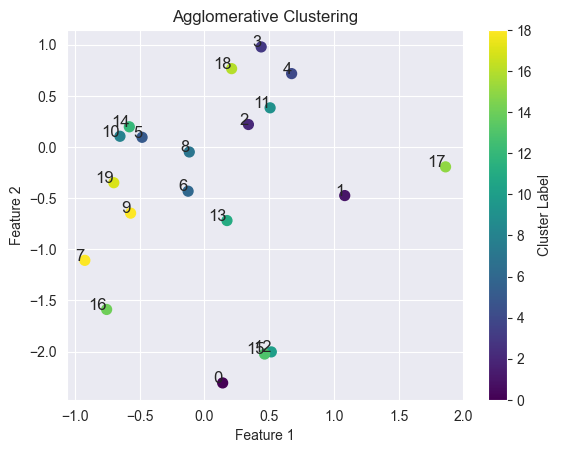

obs: 0.4109620689338431
level:  1


In [3]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=5, cluster_std=1,random_state=42)
n=20
p=2
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=19,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob= model.merge_inference(node, grid_width=20,ncoarse=20,ngrid=1000)
#pvalue, obs,sel_prob = model.merge_inference(node, grid_width=15,ncoarse=20,ngrid=1000)

In [4]:
pvalue

np.float64(0.6760982136695172)

In [5]:
model.existing_clusters_log

{(ClusterNode(points=[7]), ClusterNode(points=[9])): [ClusterNode(points=[0]),
  ClusterNode(points=[1]),
  ClusterNode(points=[2]),
  ClusterNode(points=[3]),
  ClusterNode(points=[4]),
  ClusterNode(points=[5]),
  ClusterNode(points=[6]),
  ClusterNode(points=[7]),
  ClusterNode(points=[8]),
  ClusterNode(points=[9]),
  ClusterNode(points=[10]),
  ClusterNode(points=[11]),
  ClusterNode(points=[12]),
  ClusterNode(points=[13]),
  ClusterNode(points=[14]),
  ClusterNode(points=[15]),
  ClusterNode(points=[16]),
  ClusterNode(points=[17]),
  ClusterNode(points=[18]),
  ClusterNode(points=[19])]}

level:  1
0.09054978600760155 0.34367889220193026
level:  1
0.2098394415027368 0.5294306959395956
level:  1
0.6563982779476331 0.9000800724424779
level:  1
0.7094273632109349 0.9293183655588004
level:  1
0.8129350541597099 0.9603009150843342
level:  1
0.8883459285490686 0.9815285763465853
level:  1
0.5625233529354453 0.8499196767133379
level:  1
0.2811801759529055 0.6244781571076736
level:  1
0.7114374403856797 0.9260570741799177
level:  1
0.4714664578145183 0.7960008253094978
level:  1
0.9316166292815368 0.989573708129963
level:  1
0.7854176398549395 0.9551215664188687
level:  1
0.017844776617251718 0.13111395816798976
level:  1
0.412176291655106 0.7613847857303954
level:  1
0.8567342109731404 0.9732028992953979
level:  1
0.8121008175185849 0.9580417393083701
level:  1
0.8145063861897126 0.9618555055691482
level:  1
0.4189639197897992 0.7509977981671717
level:  1
0.19538499377086616 0.5386879959974122
level:  1
0.9979316011046099 0.9998922128220918
level:  1
0.9393876161254415 0.99135

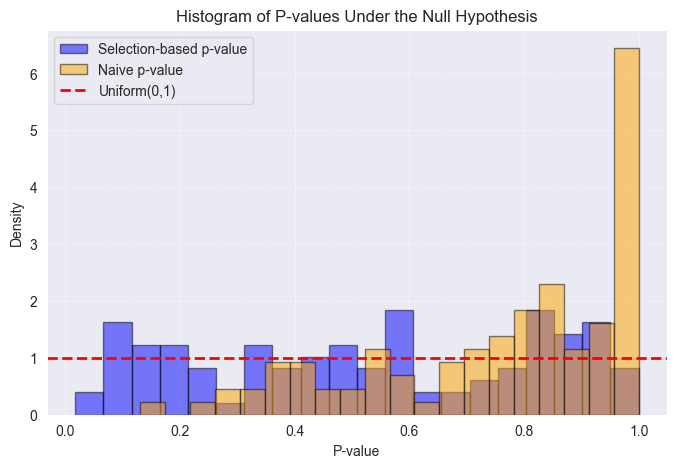

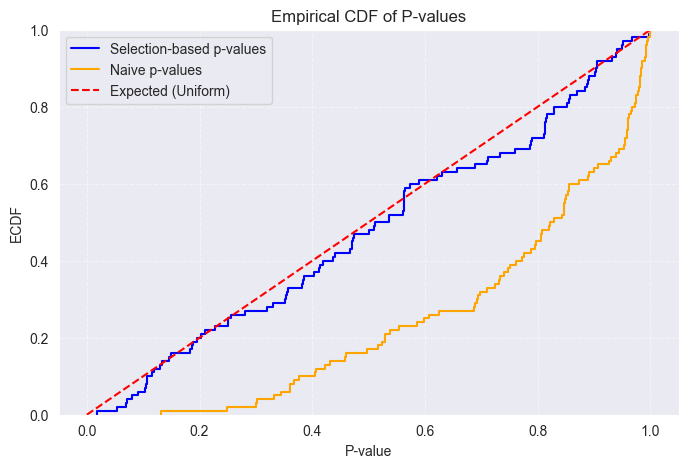

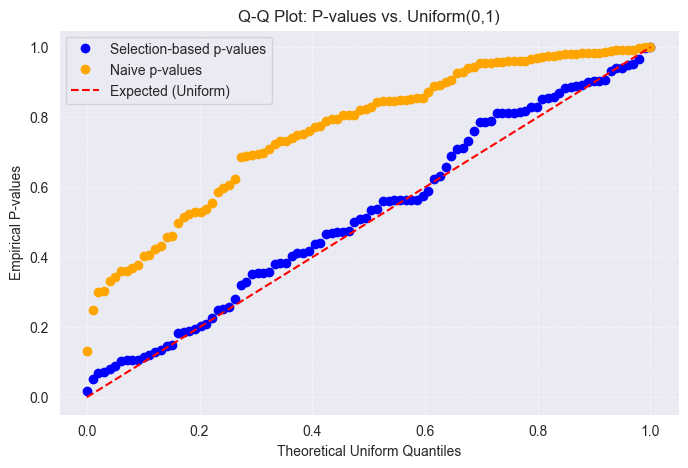

In [4]:
check_p_value_uniformity(20,20,1,19,1,-1,100)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
0.5681413284695188 0.2409824670219347
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
0.2983821659000832 0.10067556422926904
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
0.587204546105052 0.590717094405483
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
0.38703198285515666 0.14218521783397875
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
0.694045212995402 0.3842367834231347
level:  15
level:  14
level:  

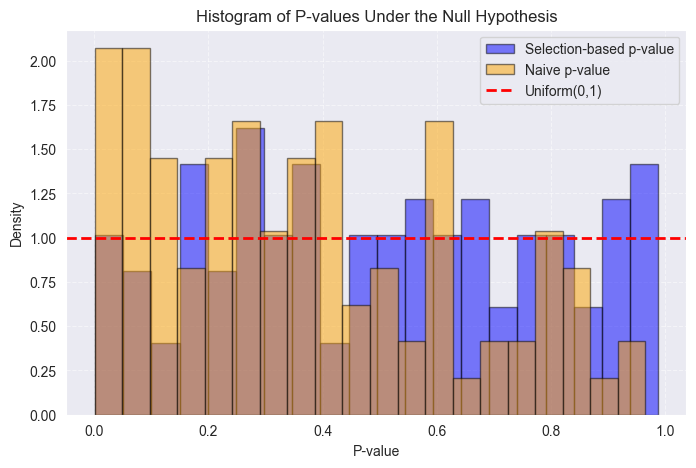

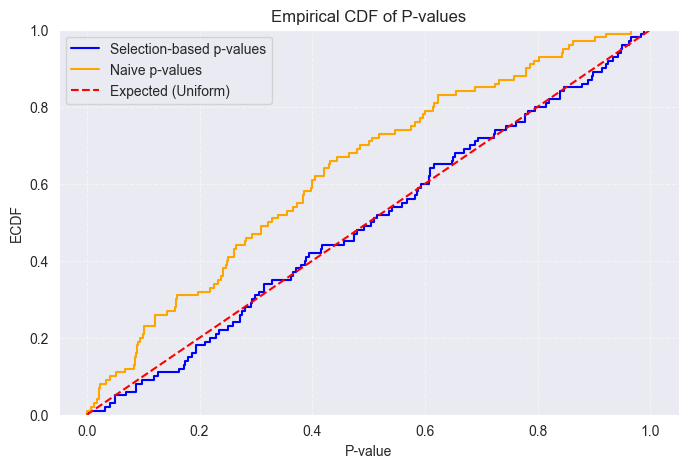

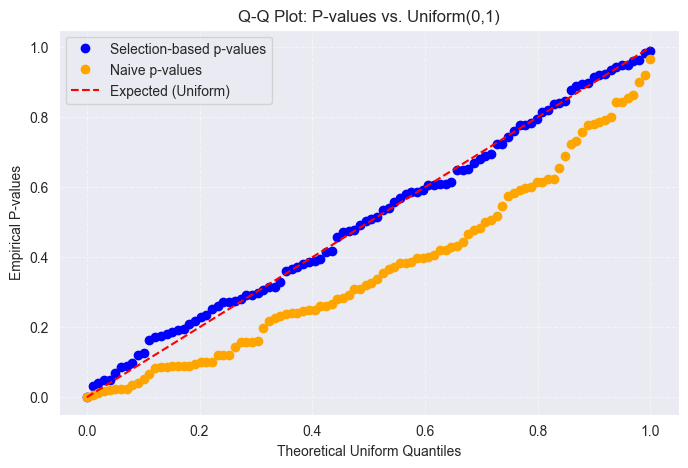

In [5]:
check_p_value_uniformity(20,20,1,5,1,-1,100)

level:  45
level:  44
level:  43
level:  42
level:  41
level:  40
level:  39
level:  38
level:  37
level:  36
level:  35
level:  34
level:  33
level:  32
level:  31
level:  30
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  45
level:  44
level:  43
level:  42
level:  41
level:  40
level:  39
level:  38
level:  37
level:  36
level:  35
level:  34
level:  33
level:  32
level:  31
level:  30
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  45
level:  44
level:

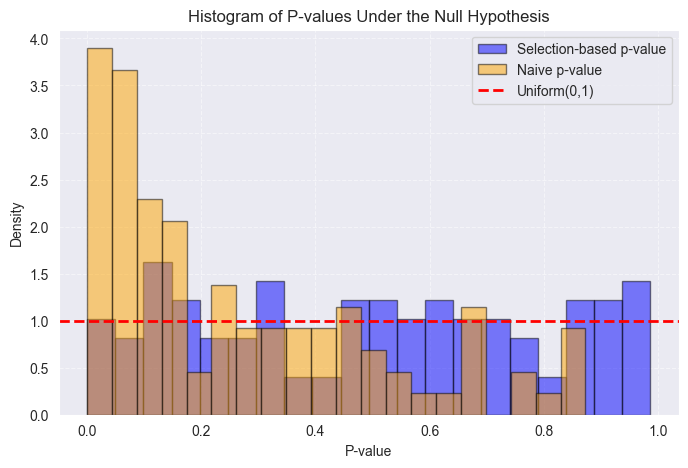

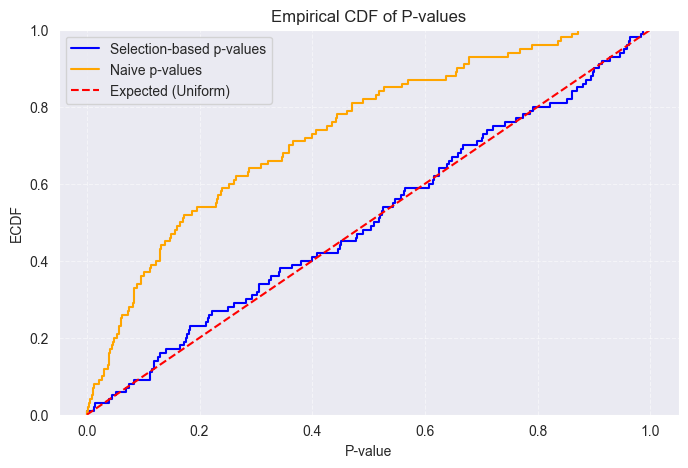

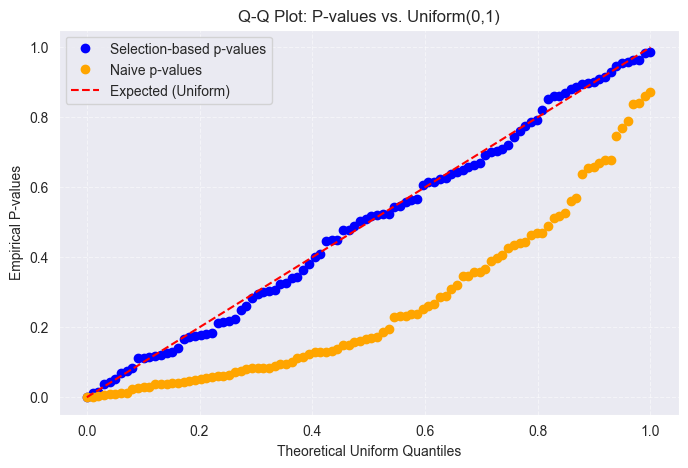

In [7]:
check_p_value_uniformity(50,20,1,5,1,-1,100)

level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
le

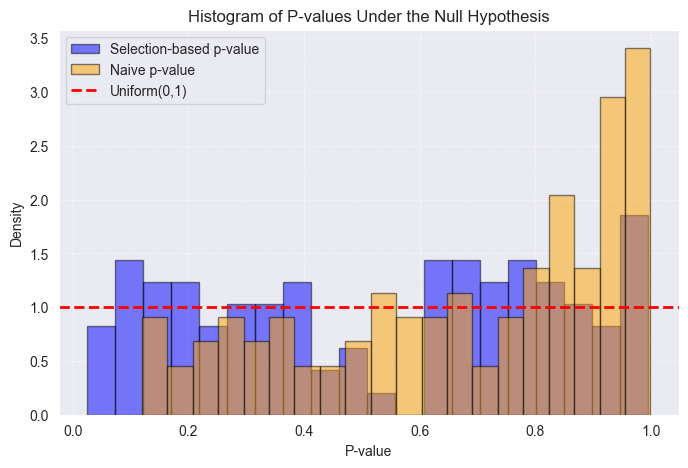

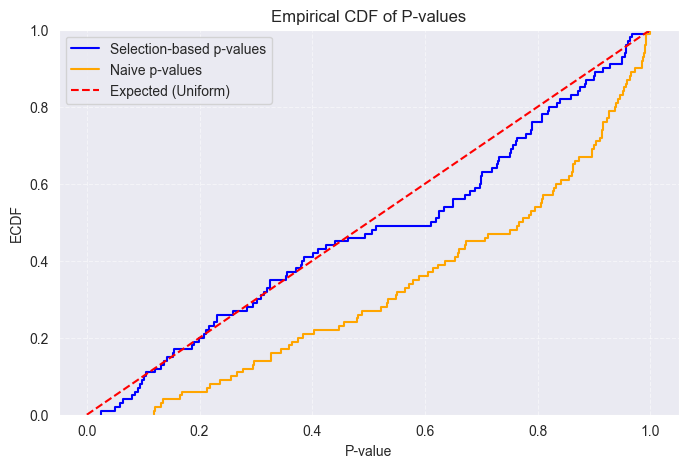

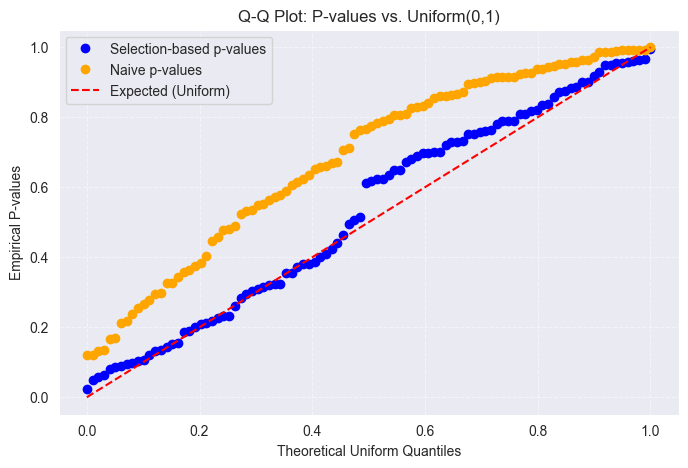

In [8]:
check_p_value_uniformity(50,30,1,5,1,10,100)

In [3]:
def check_p_value_uniformity_multi_tau(n, p, sigma, K, tau_list, layer, num_trials=1000):
    all_p_values = {}
    all_p_values_n = {}
    mu = np.zeros(p)

    for tau in tau_list:
        p_values = []
        p_values_n = []

        for _ in range(num_trials):
            X = generate_null_data(n, p, mu, sigma)
            model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage="single")
            model.fit()

            winning_nodes = list(model.existing_clusters_log.keys())
            key = winning_nodes[layer]
            node = key[0].parent
            p_val, _, _ = model.merge_inference(node, grid_width=20, ncoarse=20, ngrid=1000, sd=sigma)
            naive_val = naive_p_value(X, node)

            p_values.append(p_val)
            p_values_n.append(naive_val)

        all_p_values[tau] = np.array(p_values)
        all_p_values_n[tau] = np.array(p_values_n)

    # Histogram
    plt.figure(figsize=(10, 6))
    for tau in tau_list:
        plt.hist(all_p_values[tau], bins=20, density=True, alpha=0.4, label=f"Sel. (tau={tau})", edgecolor='black')
        plt.hist(all_p_values_n[tau], bins=20, density=True, alpha=0.4, label=f"Naive (tau={tau})", edgecolor='gray', linestyle='dashed')
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # ECDF plot
    plt.figure(figsize=(10, 6))
    for tau in tau_list:
        sns.ecdfplot(all_p_values[tau], label=f"Sel. (tau={tau})", linestyle="-")
        sns.ecdfplot(all_p_values_n[tau], label=f"Naive (tau={tau})", linestyle="--")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("ECDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot
    plt.figure(figsize=(10, 6))
    theoretical_quantiles = np.linspace(0, 1, num_trials)
    for tau in tau_list:
        sorted_sel = np.sort(all_p_values[tau])
        sorted_naive = np.sort(all_p_values_n[tau])
        plt.plot(theoretical_quantiles, sorted_sel, marker='o', linestyle='', label=f"Sel. (tau={tau})")
        plt.plot(theoretical_quantiles, sorted_naive, marker='x', linestyle='', label=f"Naive (tau={tau})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


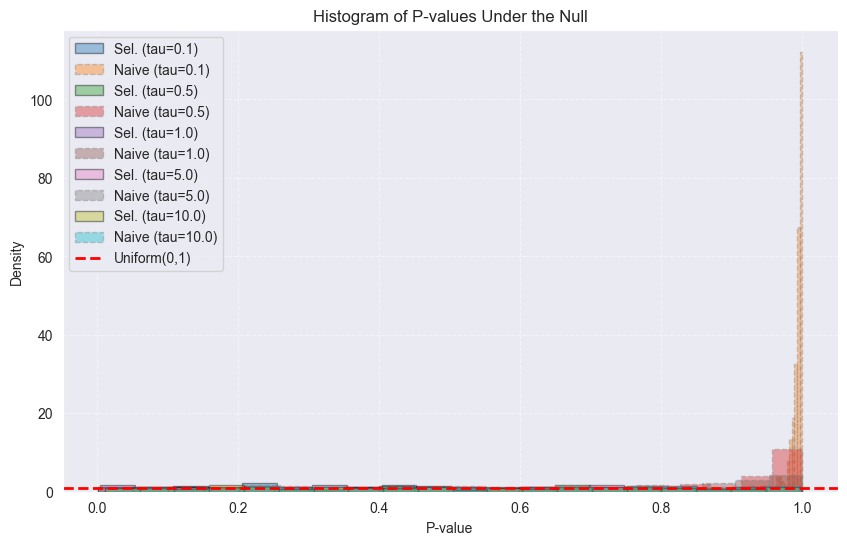

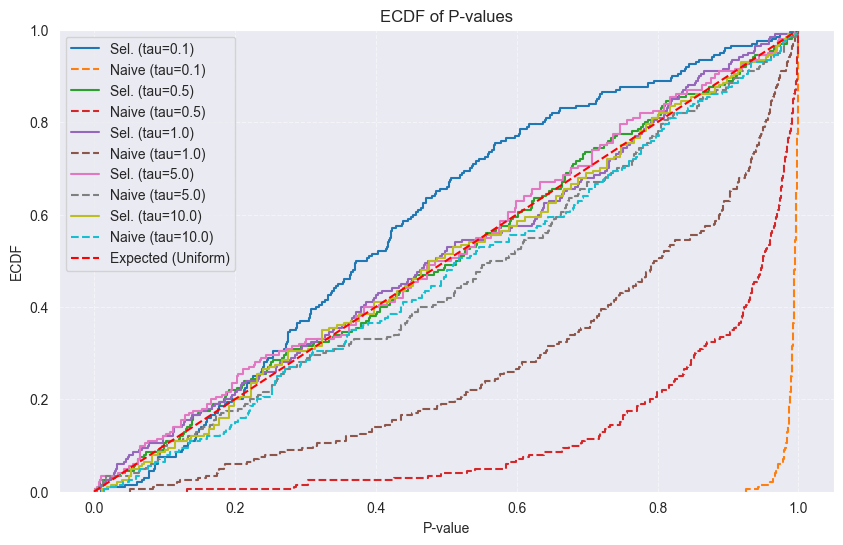

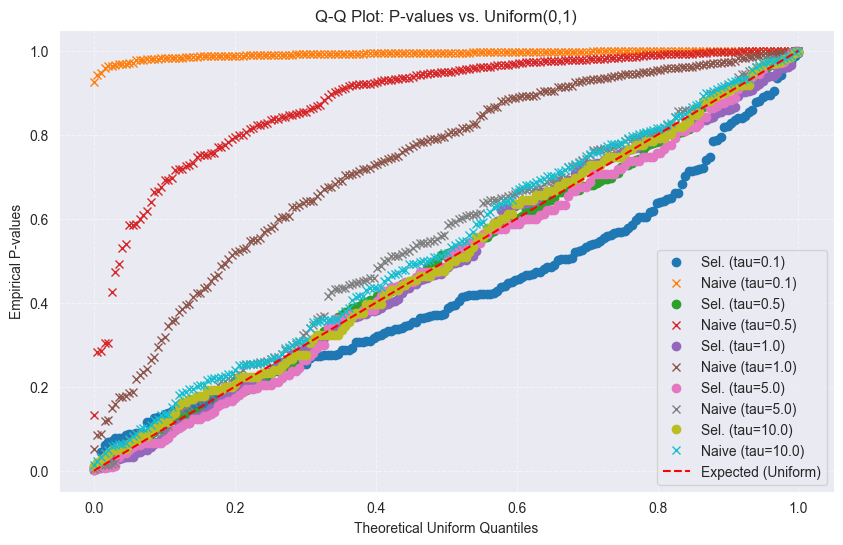

In [4]:
tau_list = np.array([0.1,0.5,1,5, 10])
check_p_value_uniformity_multi_tau(20,20,1,19,tau_list,-1,200)

level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  15
level:  14
level:  13
level:  12
level:  11
level:  1

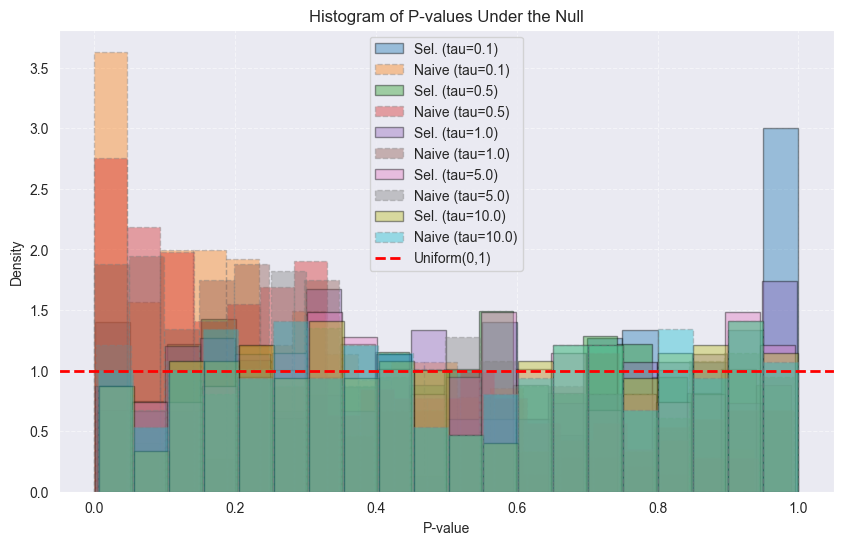

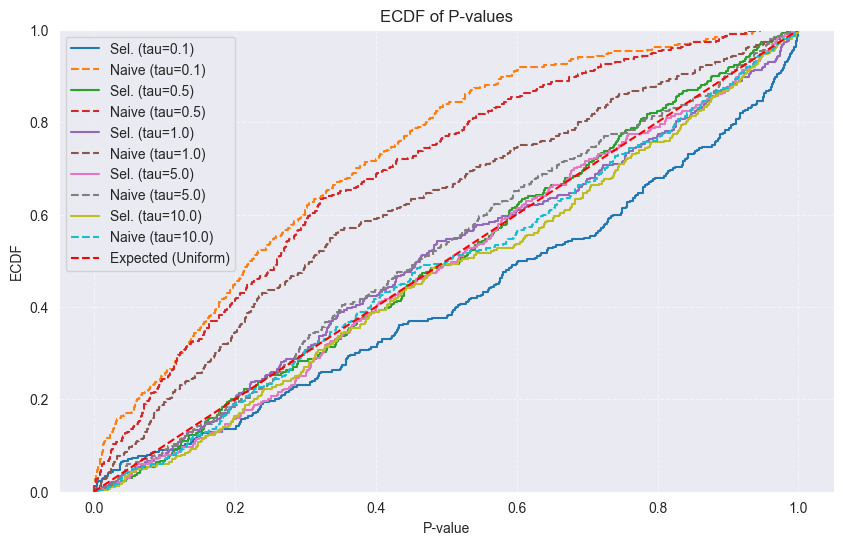

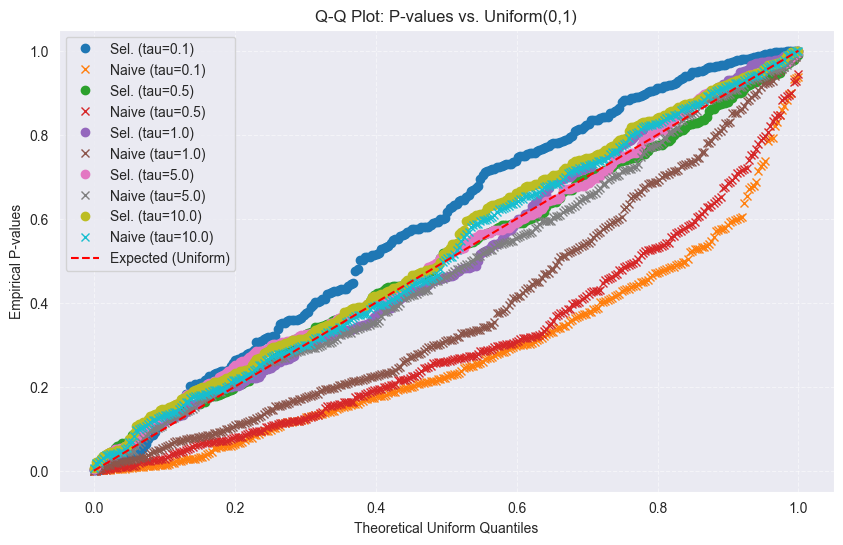

In [6]:
tau_list = np.array([0.1,0.5,1,5, 10])
check_p_value_uniformity_multi_tau(20,20,1,5,tau_list,-1,300)